### Imports

In [28]:
%config InlineBackend.figure_format = 'svg'

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pickle
from models import NonLinearController, ClosedLoopSystem, NonLinearController_p2, Double_closed_loop
# from Rens import REN_IQC_gamma, DualREN
from utils import set_params, set_QR, ensure_3d, fun_start_controller, fun_start_controller_simple
from torch.utils.data import DataLoader, random_split, Subset, SubsetRandomSampler, Dataset, TensorDataset
from ParametersFunctions import Parameter, PID_functions, MinMaxScalerTorch
from pathlib import Path
import scipy.io as sio
from dataset import LoadData, SimpleLoadData

from neural_ssm import DeepSSM



# model = DeepSSM(d_input=1, d_output=1, param='l2n')  #lru   l2n gamma prescritto
# y, _ = model(torch.tensor([5.0]))
# print(y)

In [29]:
class REN_IQC_gamma(nn.Module):

    def __init__(
        self, dim_in: int, dim_out: int, dim_internal: int,
        dim_nl: int, internal_state_init = None, y_init = None,
        initialization_std: float = 0.5, pos_def_tol: float = 0.001, gammat=None, QR_fun=None, IQC_type='l2_gain',
        Q=None, R=None, S=None, device='cpu'
    ):
        """
        Args:
            dim_in (int): Input (u) dimension.
            dim_out (int): Output (y) dimension.
            dim_internal (int): Internal state (x) dimension. This state evolves with contraction properties.
            dim_nl (int): Dimension of the input ("v") and ouput ("w") of the nonlinear static block.
            initialization_std (float, optional): Weight initialization. Set to 0.1 by default.
            internal_state_init (torch.Tensor or None, optional): Initial condition for the internal state. Defaults to 0 when set to None.
            epsilon (float, optional): Positive and negligible scalar to force positive definite matrices.
            gamma (float, optional):  Defaults to 1.
        """
        super().__init__()
        
        self.device = device

        # set dimensions
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.dim_internal = dim_internal
        self.dim_nl = dim_nl

        # set functionalities

        self.IQC_type = IQC_type
        self.QR_fun = QR_fun
        self.Q = Q
        self.R = R
        self.S = S
        

        # auxiliary elements
        self.epsilon = pos_def_tol

        # # # free parameters except for D22
        # define matrices shapes
        # auxiliary matrices
        self.X_shape = (2 * dim_internal + dim_nl, 2 * dim_internal + dim_nl)
        self.Y_shape = (dim_internal, dim_internal)
        # nn state dynamics
        self.B2_shape = (dim_internal, dim_in)
        # nn output
        self.C2_shape = (dim_out, dim_internal)
        self.D21_shape = (dim_out, dim_nl)
        self.D22_shape = (dim_out, dim_in)


        # v signal
        self.D12_shape = (dim_nl, dim_in)

        self.s = np.max((dim_in, dim_out))
        # self.X3_shape = (self.s, self.s)
        # self.Y3_shape = (self.s, self.s)
        # self.Z3_shape = (abs(dim_out - dim_in), min(dim_out, dim_in))

        self.gamma_shape = (1, 1)
        self.gammat = gammat
        self.device = device

        # define trainable params
        self.training_param_names = ['X', 'Y', 'B2', 'C2', 'D21', 'D12']
        if self.gammat is None:
            self.training_param_names.append('gamma')
        else:
            self.gamma = gammat

        # initialize trainable parameters
        self._init_trainable_params(initialization_std)

        # register buffers (non-trainable masks)
        self.register_buffer('eye_mask_min', torch.eye(min(dim_in, dim_out), device=device))
        self.register_buffer('eye_mask_dim_in', torch.eye(dim_in, device=device))
        self.register_buffer('eye_mask_dim_out', torch.eye(dim_out, device=device))
        self.register_buffer('eye_mask_dim_state', torch.eye(dim_internal, device=device))
        self.register_buffer('eye_mask_H', torch.eye(2 * dim_internal + dim_nl, device=device))
        self.register_buffer('zeros_mask_S', torch.zeros(dim_in, dim_out, device=device))
        self.register_buffer('zeros_mask_Q', torch.zeros(dim_out, dim_out, device=device))
        self.register_buffer('zeros_mask_R', torch.zeros(dim_in, dim_in, device=device))
        self.register_buffer('zeros_mask_so', torch.zeros(dim_internal, dim_out, device=device))
        self.register_buffer('eye_mask_w', torch.eye(dim_nl, device=device))
        
        batch_size = 1  # default batch size

        # initialize internal state
        if internal_state_init is not None:
            assert isinstance(internal_state_init, torch.Tensor)
            self.x = internal_state_init.reshape(1, 1, dim_internal)
        elif y_init is not None:
            batch_size = y_init.shape[0]
            self.C2 = nn.Parameter(self.C2.data)  # C2 already inizializzato come Parameter
            self.x = torch.stack([
                torch.linalg.lstsq(self.C2, y_init[b, 0, :].unsqueeze(1))[0].T
                for b in range(batch_size)
            ], dim=0).unsqueeze(1)
            # self.x = torch.linalg.lstsq(self.C2, y_init.squeeze(1).T)[0].T.unsqueeze(0).unsqueeze(0)
        else:
            self.x = torch.zeros(1, 1, dim_internal)

        # register initial state buffers
        self.register_buffer('x_init', self.x.detach().clone())
        y_init_calc = F.linear(self.x_init, self.C2)
        y_init_calc = y_init_calc.view(batch_size, 1, self.dim_out)
        self.register_buffer('y_init', y_init_calc)

        # move everything to device
        self.to(device)

        # esplicito solo stato interno (già incluso in buffers), ma per sicurezza
        self.x = self.x.to(device)
        

    def _update_model_param(self):
        """
        Update non-trainable matrices according to the REN formulation to preserve IQC.
        """
        dim_internal, dim_nl, dim_in, dim_out = self.dim_internal, self.dim_nl, self.dim_in, self.dim_out

        if self.QR_fun is not None:
            self.Q, self.R, self.S = self.QR_fun(self.gamma, dim_in, dim_out, self.IQC_type)
        else:
            # monotone
            eps = 1e-4

            # monotone on l2
            self.Q = torch.zeros(self.dim_out, self.dim_out) -eps * torch.eye(self.dim_out) # 0
            self.R = - 2 * self.gamma * torch.eye(self.dim_in, self.dim_in)  # -2 nu I
            self.S = torch.eye(self.dim_out, self.dim_in)  # I


        self.D22 = torch.zeros(self.dim_out, self.dim_in)

        # psi terms (keep same)
        R_cal = self.R
        R_cal_inv = torch.inverse(R_cal)
        C2_cal = torch.matmul(torch.matmul(self.D22.T, self.Q) + self.S, self.C2)
        D21_cal = torch.matmul(torch.matmul(self.D22.T, self.Q) + self.S, self.D21) - self.D12.T
        
        vec_r = torch.cat((C2_cal.T, D21_cal.T, self.B2), dim=0)
        psi_r = torch.matmul(vec_r, torch.matmul(R_cal_inv, vec_r.T))

        vec_q = torch.cat((self.C2.T, self.D21.T, self.zeros_mask_so), dim=0)
        psi_q = torch.matmul(vec_q, torch.matmul(self.Q, vec_q.T))

        H = torch.matmul(self.X.T, self.X) + self.epsilon * self.eye_mask_H + psi_r - psi_q
        
        h1, h2, h3 = torch.split(H, [dim_internal, dim_nl, dim_internal], dim=0)
        H11, H12, H13 = torch.split(h1, [dim_internal, dim_nl, dim_internal], dim=1)
        H21, H22, _ = torch.split(h2, [dim_internal, dim_nl, dim_internal], dim=1)
        H31, H32, H33 = torch.split(h3, [dim_internal, dim_nl, dim_internal], dim=1)
        self.P_cal = H33
        # NN state dynamics:
        self.F = H31
        self.B1 = H32
        # NN output:
        self.E = 0.5 * (H11 + self.P_cal + self.Y - self.Y.T)
        self.E_inv = self.E.inverse()
        # v signal:  [Change the following 2 lines if we don't want a strictly acyclic REN!]
        self.Lambda = 0.5 * torch.diag(H22)
        self.D11 = -torch.tril(H22, diagonal=-1)
        self.C1 = -H21
        # Matrix P
        #self.P = torch.matmul(self.E.T, torch.matmul(torch.inverse(self.P_cal), self.E))

    def forward(self, u_in):
        """
        Forward pass of REN.

        Args:
            u_in (torch.Tensor): Input with the size of (batch_size, 1, self.dim_in).

        Return:
            y_out (torch.Tensor): Output with (batch_size, 1, self.dim_out).
        """
        # update non-trainable model params
        self._update_model_param()

        batch_size = u_in.shape[0]

        w = torch.zeros(batch_size, 1, self.dim_nl, device=u_in.device)

        # update each row of w using Eq. (8) with a lower triangular D11
        for i in range(self.dim_nl): # does the non linear one by one but all together the multiple batches
            #  v is element i of v with dim (batch_size, 1)
            v = F.linear(self.x, self.C1[i, :]) + F.linear(w, self.D11[i, :]) + F.linear(u_in, self.D12[i, :])
            w = w + (self.eye_mask_w[i, :] * torch.tanh(v / self.Lambda[i])).reshape(batch_size, 1, self.dim_nl) # w dim [batch 1 dim_nl]


        # compute next state using Eq. 18
        self.x = F.linear(F.linear(self.x, self.F) + F.linear(w, self.B1) + F.linear(u_in, self.B2), self.E_inv)

        # compute output
        y_out = F.linear(self.x, self.C2) + F.linear(w, self.D21) # + F.linear(u_in, self.D22)
        return y_out

    def reset(self, x0=None, y0= None):
        """
        Reset compatibile con ClosedLoopSystem.
        Se x0 è fornito (shape (batch, 1, dim_internal) o (1, 1, dim_internal)),
        lo utilizza come stato; altrimenti usa self.x_init (replicato per batch se necessario).
        """
        batch_size = y0.shape[0]
        if x0 is not None:
            # accetta sia (1,1,dim) sia (batch,1,dim)
            self.x = x0.clone().to(self.device)
        elif y0 is not None:
            self.x = torch.stack([
                torch.linalg.lstsq(self.C2, y0[b, 0, :].unsqueeze(1))[0].T
                for b in range(batch_size)
                ], dim=0).to(self.device)
            self.y_init = y0.detach().clone().to(self.device)
        else:
            # default behaviour: reset to x_init, replicate to batch_size se richiesto
            if batch_size is None:
                self.x = self.x_init.clone().to(self.device)
            else:
                self.x = self.x_init.detach().clone().repeat(batch_size, 1, 1).to(self.device)


    def y0_from_x0(self, x0: torch.Tensor) -> torch.Tensor:
        """
        Given an internal state x0 (batch,1,dim_internal) returns the corresponding y0.
        We assume initial w = 0 and u = 0, so y0 = C2 @ x0 (linear part).
        """
        return F.linear(x0, self.C2)


    def run(self, u_in, x0=None, y0=None):
        """
        Runs the forward pass of REN for a whole input sequence of length horizon.

        Args:
            u_in (torch.Tensor): Input with the size of (batch_size, horizon, self.dim_in).

        Return:
            y_out (torch.Tensor): Output with (batch_size, horizon, self.dim_out).
        """

        self.reset(x0 = x0, y0 = y0)
        if y0 is not None:
            y_log = y0.detach().clone()
        else:
            y_log = self.y_init.detach().clone()
       
            
        for t in range(u_in.shape[1] - 1):
            y_log = torch.cat((y_log, self.forward(u_in[:, t:t + 1, :])), 1)
        # note that the last input is not used
        return y_log

    # init trainable params
    def _init_trainable_params(self, initialization_std):
        for training_param_name in self.training_param_names:  # name of one of the training params, e.g., X
            # read the defined shapes of the selected training param, e.g., X_shape
            shape = getattr(self, training_param_name + '_shape')
            # define the selected param (e.g., self.X) as nn.Parameter
            if training_param_name == 'gamma':
                initialization_std = 3
            setattr(self, training_param_name, nn.Parameter((torch.randn(*shape) * initialization_std)))

    # setters and getters
    def get_parameter_shapes(self):
        param_dict = OrderedDict(
            (name, getattr(self, name).shape) for name in self.training_param_names
        )
        return param_dict

    def get_named_parameters(self):
        param_dict = OrderedDict(
            (name, getattr(self, name)) for name in self.training_param_names
        )
        return param_dict

    def __call__(self,u_in, x0=None, y0=None):
        return self.run(u_in, x0, y0)

### REN model 101, loss function and optimizer parallel
as strategy 1

Epoch 0, Loss: 0.167246
Epoch 10, Loss: 0.164581
Epoch 20, Loss: 0.163511
Epoch 30, Loss: 0.163354
Epoch 40, Loss: 0.163375
Epoch 50, Loss: 0.163349
Epoch 60, Loss: 0.163337
Epoch 70, Loss: 0.163336
Epoch 80, Loss: 0.163335
Epoch 90, Loss: 0.163334
Epoch 100, Loss: 0.163334
Epoch 110, Loss: 0.163334
Epoch 120, Loss: 0.163333
Epoch 130, Loss: 0.163333
Epoch 140, Loss: 0.163333
Epoch 150, Loss: 0.163333
Epoch 160, Loss: 0.163333
Epoch 170, Loss: 0.163333
Epoch 180, Loss: 0.163333
Epoch 190, Loss: 0.163333
Epoch 200, Loss: 0.163333
Epoch 210, Loss: 0.163333
Epoch 220, Loss: 0.163333
Epoch 230, Loss: 0.163333
Epoch 240, Loss: 0.163333
Epoch 250, Loss: 0.163333
Epoch 260, Loss: 0.163333
Epoch 270, Loss: 0.163333
Epoch 280, Loss: 0.163333
Epoch 290, Loss: 0.163333
Epoch 300, Loss: 0.163333
Epoch 310, Loss: 0.163333
Epoch 320, Loss: 0.163333
Epoch 330, Loss: 0.163333
Epoch 340, Loss: 0.163333
Epoch 350, Loss: 0.163333
Epoch 360, Loss: 0.163333
Epoch 370, Loss: 0.163333
Epoch 380, Loss: 0.1633

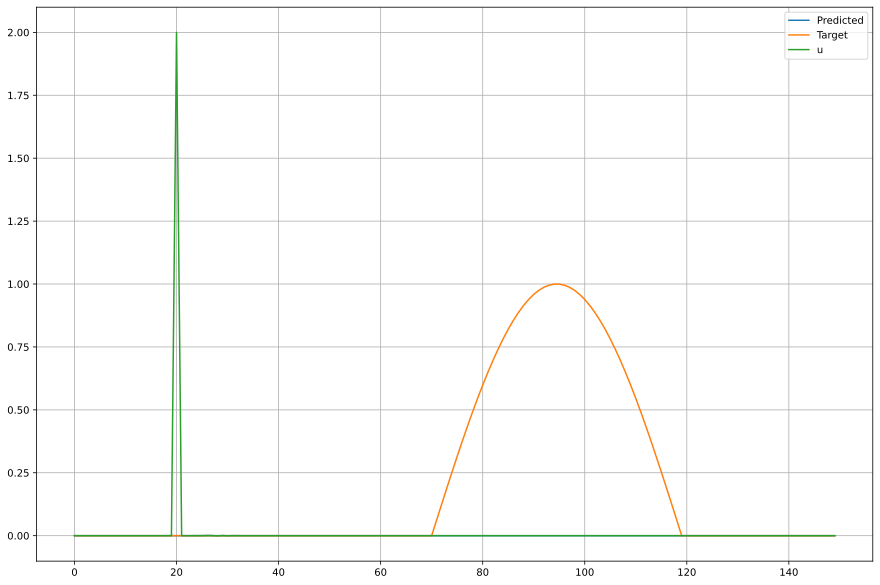

In [30]:
# input pos
flag_y_ref_pos = True   # True 
#if true the y ref is positive, if false is Negative



delay_input_output = 50

epochs = 1000

gamma = torch.tensor([40])

# --------------------------


y_pos = torch.cat([
    torch.zeros(20+delay_input_output),
    torch.sin(torch.linspace(0, torch.pi, 50)),
    torch.zeros(80-delay_input_output)
])

u = torch.cat([
    torch.zeros(20),
    torch.tensor([2.0]),
    torch.zeros(129)
])

# reshape (T, dim_in)
u = u[:, None].float()        # (T, 1)
y_pos = y_pos[:, None].float()  # (T, 1)
y_neg = -y_pos

T = u.shape[0]

# -------------------------- 2. Define dataset and loader ------------------------------------
# Add batch dimension: (1, T, 1)
dataset_pos = TensorDataset(u[None, :, :], y_pos[None, :, :])
dataset_neg = TensorDataset(u[None, :, :], y_neg[None, :, :])

loader_pos = DataLoader(dataset_pos, batch_size=1, shuffle=False)
loader_neg = DataLoader(dataset_neg, batch_size=1, shuffle=False)

# -------------------------- 3. Define model ---------------------------------------------

y0_0 = torch.zeros(1)[None,:,None]

SSM_prova = DeepSSM(d_input=1, d_output=1, d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
REN_prova = REN_IQC_gamma(dim_in= 1, dim_out= 1, dim_internal=8, dim_nl= 8, y_init = y0_0, gammat = gamma)



# Loss and optimizer
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(REN_prova.parameters(), lr=0.001)
# optimizer = torch.optim.Adam( SSM_prova.parameters(), lr=0.001)

# -------------------------- 4. Training loop ---------------------------------------------

train_losses = []

if flag_y_ref_pos:
    loader = loader_pos
else: 
    loader = loader_neg

for epoch in range(epochs):
    REN_prova.train()
    SSM_prova.train()
    epoch_loss = 0.0
    for u_batch, y_batch in loader:
        optimizer.zero_grad()
        
        y_hat = REN_prova(u_batch, y0 = y_batch[:,:1,:1])  
        # y_hat_SSM, _ = SSM_prova(u_batch)
        
        # loss = MSE(y_hat_SSM, y_batch)
        loss = MSE(y_hat, y_batch)
        
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss:.6f}")
    
    if epoch == epochs-1:
        
        plt.figure(figsize=(15,10))
        plt.plot(y_hat[0,:,0].detach().numpy(), label='Predicted')
        # plt.plot(y_hat_SSM[0,:,0].detach().numpy(), label='Predicted SSM')
        plt.plot(y_batch[0,:,0].detach().numpy(), label='Target')
        plt.plot(u_batch[0,:,0].detach().numpy(), label='u')
        plt.grid()
        plt.legend()
        plt.show()
        
        

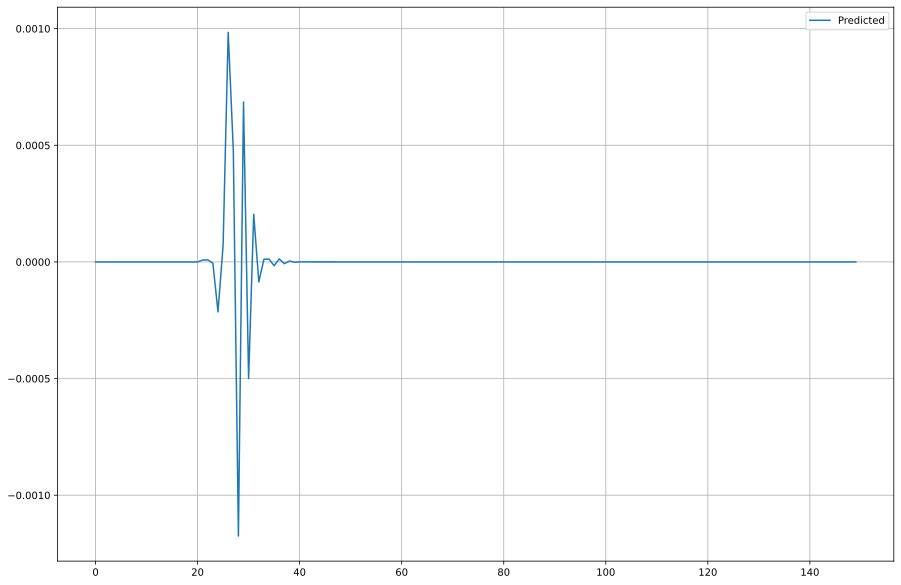

In [31]:

plt.figure(figsize=(15,10))
plt.plot(y_hat[0,:,0].detach().numpy(), label='Predicted')
# plt.plot(y_hat_SSM[0,:,0].detach().numpy(), label='Predicted SSM')
# plt.plot(y_batch[0,:,0].detach().numpy(), label='Target')
# plt.plot(u_batch[0,:,0].detach().numpy(), label='u')
plt.grid()
plt.legend()
plt.show()